# Working with AWS Data

#### A tutorial by Simon Ramirez

## 0. Imports and Setup

In [ ]:
# For Configuration File
import yaml
from pathlib import Path
import importlib

config_path = ### Enter Config File Path Here

# Load Config File
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# Config Variables
name = config["name"]
seismic_path = config["seismic_data_path"]
seismic_data = Path(config['seismic_data_path'])
aws_path = config['aws_data_path']
seiswind_module = config['seiswind_module']

# obspy GitHub:
# https://github.com/obspy/obspy
from obspy import UTCDateTime as UTC

# seismic-weather GitHub:
# https://github.com/Ramirezs873/seismic-weather
spec = importlib.util.spec_from_file_location("seismicwind", seiswind_module)
seismicwind = importlib.util.module_from_spec(spec)
spec.loader.exec_module(seismicwind)

In [2]:
# Load class Seismic
## Load with config file
seis = seismicwind.Seismic(config=config)

## 1. Load Seismic Data

Since seismicwind is structured for simultaneous seismic and AWS analysis, seismic data must be loaded before AWS data can be inspected.

To gather seismic data, call get_seis() in the Seismic class.

get_seis() retrieves seismic data from a sensor through an FDSN client for the given specifications and saves it as an mseed file. If The data has previously been stored locally, then the function instead opens the file.


In [3]:
# Gather Data
## Station CASY used as an example
data = seis.get_seis(client = 'IRIS',
                     network = 'IU',
                     station = 'CASY',
                     location = '00',
                     channel = 'BH?',
                     t_start = UTC(2022, 12, 24, 23, 0,0),
                     t_end = UTC(2023, 1, 1, 1, 1, 0),
                     username = None,
                     password = None,
                     file_name = 'CASY_2022_Christmas')

Reading existing file: C:\Users\simon\Desktop\UTAS\Honours Research\Workspace\CASY_2022_Christmas.mseed


## 2. Load AWS Data

To gather AWS data, call get_aws() in the Wind subclass.

get_aws() retrieves AWS data from a locally stored .txt or .parquet file. The file must be titled 'HM01X_Data_{station_code}_{id_code}'. 

In [4]:
aws = data.wind.get_aws(path=aws_path, station_code='300060', id_code='55510926053')

The aws data is stored as a Pandas DataFrame.

In [5]:
aws

,Station Number,Precipitation since 9am local time in mm,Quality of precipitation since 9am local time,Air Temperature in degrees C,Quality of air temperature,Wet bulb temperature in degrees C,Quality of Wet bulb temperature,Dew point temperature in degrees C,Quality of dew point temperature,Relative humidity in percentage %,...,Speed of maximum windgust in last 10 minutes in km/h,Quality of speed of maximum windgust in last 10 minutes,Mean sea level pressure in hPa,Quality of mean sea level pressure,Station level pressure in hPa,Quality of station level pressure,QNH pressure in hPa,Quality of QNH pressure,AWS Flag,datetime
0,300060,,,1.9,N,-0.1,N,-3.6,N,67,...,5.4,N,998.9,N,950.9,N,997.3,N,1,2010-01-05 08:30:00
1,300060,,,1.8,N,-0.1,N,-3.5,N,68,...,7.6,N,998.9,N,950.8,N,997.2,N,1,2010-01-05 09:00:00
2,300060,,,2.3,N,0.4,N,-3.2,N,67,...,3.6,N,998.9,N,950.9,N,997.3,N,1,2010-01-05 09:30:00
3,300060,,,,,,,,,,...,9.4,N,,,,,997.3,N,1,2010-01-05 10:00:00
4,300060,,,1.4,N,-0.5,N,-4.0,N,67,...,3.6,N,999.1,N,951.0,N,997.4,N,1,2010-01-05 10:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118702,300060,,,-0.3,N,-3.5,N,-11.9,N,41,...,7.6,N,996.7,N,948.3,N,994.6,N,1,2025-12-01 02:00:00
118703,300060,,,-1.3,N,-4.2,N,-12.5,N,42,...,5.4,N,996.7,N,948.2,N,994.5,N,1,2025-12-01 02:30:00
118704,300060,,,-0.6,N,-3.6,N,-11.6,N,43,...,5.4,N,996.5,N,948.1,N,994.4,N,1,2025-12-01 03:00:00
118705,300060,,,-0.1,N,-2.9,N,-9.8,N,48,...,9.4,N,996.4,N,948.1,N,994.4,N,1,2025-12-01 03:30:00


## 3. Inspecting Variables

The function get_var() allows a specific aws variable from the dataset to be inspected. 

At the moment, this function currently returns the time array, aws variable array, and also the wind direction array. Wind direction is currently only stored as default for simple seismic-wind analysis. In the future, this may be changed.

In [6]:
wind = data.wind.get_var(variable='Wind speed in km/h',
                         year = 2022, 
                         month = 12, 
                         day = (25,31), 
                         hour = None) # None returns all

## 4. Plotting AWS Variables

The selected AWS variable can be plotted with plot_aws().

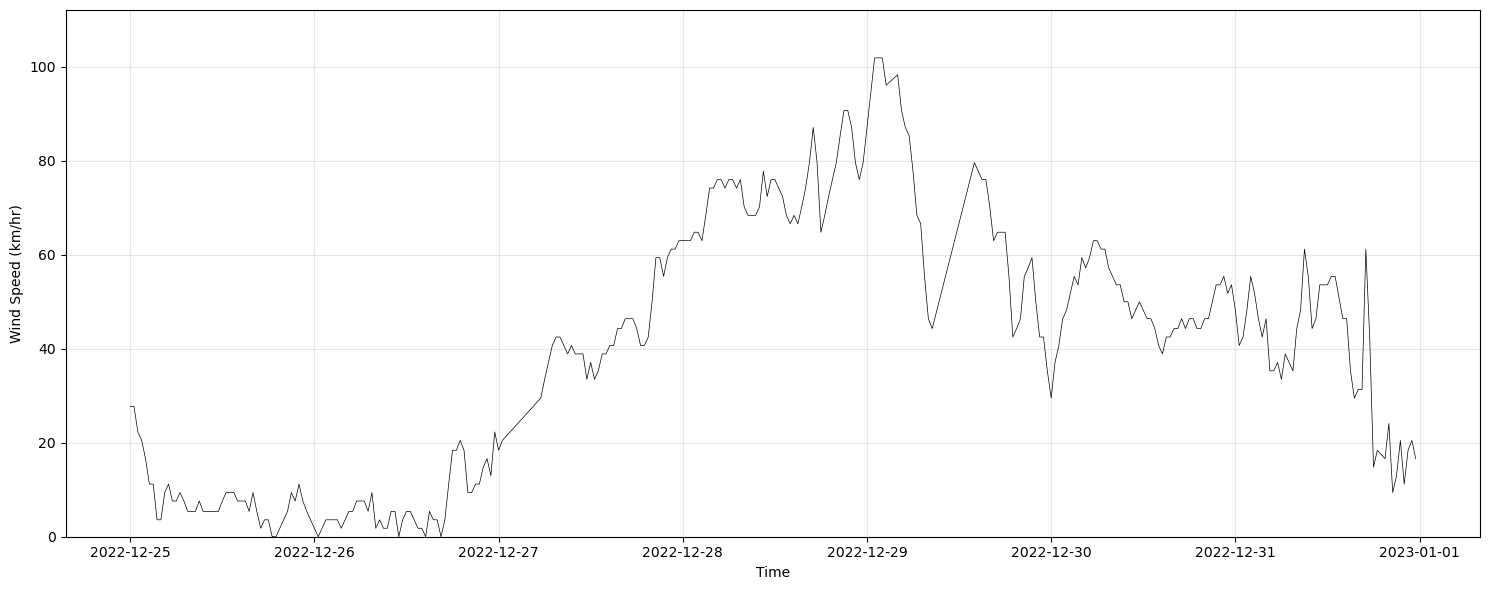

In [7]:
data.wind.plot_aws(ylabel = 'Wind Speed (km/hr)')

Wind speed and wind direction can also be visualised on a polar plot using plot_rose_wind().

In [8]:
data.wind.plot_rose_wind(year=None, 
                         month=None, 
                         day=None,
                         hour=None)

C:\\Users\\simon\\Desktop\\UTAS\\Honours Research\\GitHub\\seismic-weather\\seismicwind.py:1205: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  freq = df_slice.groupby(['dir_bin', 'speed_bin']).size().reset_index(name='count')
